# PrediRuta: construcción de los datasets finales

Este notebook parte de los **seis CSV relacionales depurados**. 
1. construye un diccionario reproducible para convertir las variables categóricas en códigos numéricos
2. construye una cuadrícula recurrente zona-mes-día-hora para modelar la ocurrencia histórica
3. incorpora una climatología consistente a todas las combinaciones de la cuadrícula
4. integra las tablas necesarias para los análisis posteriores

## 0. Configuración

In [1]:
# Librerías y parámetros generales
from pathlib import Path
from itertools import product
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyproj import Transformer
from scipy.spatial import cKDTree
from sklearn.cluster import MiniBatchKMeans

In [2]:
# Configuración de rutas y carpetas
CARPETA_TABLAS = Path('data_procesada') / 'tablas_finales'
CARPETA_CACHE_CLIMA = Path('data_procesada') / 'cache_clima_hibrido'
CARPETA_SALIDA = Path('data_procesada') / 'modelado'

# Crear carpeta de salida si no existe
CARPETA_SALIDA.mkdir(parents=True, exist_ok=True)

# Rutas de salida de archivos
RUTA_DICCIONARIO = CARPETA_SALIDA / 'DICCIONARIO_CATEGORIAS.csv'
RUTA_OCURRENCIA = CARPETA_SALIDA / 'DATASET_OCURRENCIA.csv'
RUTA_EVENTOS = CARPETA_SALIDA / 'DATASET_EVENTOS.csv'
RUTA_MODELADO = CARPETA_SALIDA / 'TABLA_COMPLETA_MODELADO.csv'

## 1. Carga de los CSV separados

Los archivos originales no se sobrescriben. Todas las transformaciones se aplican sobre copias en memoria.

In [3]:
# Archivos de entrada
ARCHIVOS = {
    'ACCIDENTE': 'ACCIDENTE.csv',
    'CLIMA': 'CLIMA.csv',
    'VIA': 'VIA.csv',
    'VEHICULO': 'VEHICULO.csv',
    'ACTOR_VIAL': 'ACTOR_VIAL.csv',
    'CAUSA': 'CAUSA.csv',
}

print('Archivos encontrados:', len(ARCHIVOS))

Archivos encontrados: 6


In [4]:
# Cargar las seis tablas
TABLAS = {}

for tabla, archivo in ARCHIVOS.items():

    ruta = CARPETA_TABLAS / archivo

    if tabla == 'ACCIDENTE':
        TABLAS[tabla] = pd.read_csv(
            ruta,
            encoding='utf-8-sig',
            low_memory=False,
            parse_dates=['FECHA_HORA']
        )

    elif tabla == 'CLIMA':
        TABLAS[tabla] = pd.read_csv(
            ruta,
            encoding='utf-8-sig',
            low_memory=False,
            parse_dates=['FECHA_HORA_CLIMA']
        )

    else:
        TABLAS[tabla] = pd.read_csv(
            ruta,
            encoding='utf-8-sig',
            low_memory=False
        )

# Resumen de tablas cargadas
inventario = pd.DataFrame([
    {
        'TABLA': tabla,
        'FILAS': len(datos),
        'COLUMNAS': len(datos.columns),
        'ARCHIVO': ARCHIVOS[tabla]
    }
    for tabla, datos in TABLAS.items()
])

display(inventario)

,TABLA,FILAS,COLUMNAS,ARCHIVO
0,ACCIDENTE,895346,7,ACCIDENTE.csv
1,CLIMA,325230,11,CLIMA.csv
2,VIA,488413,12,VIA.csv
3,VEHICULO,1669752,4,VEHICULO.csv
4,ACTOR_VIAL,1927486,7,ACTOR_VIAL.csv
5,CAUSA,1283835,6,CAUSA.csv


## 2. Diccionario de variables categóricas

En esta sección se identifican las variables categóricas presentes en cada una de las tablas y se construye un diccionario que permita convertir sus valores a códigos numéricos.

Cada combinación de tabla y columna cuenta con su propio catálogo de categorías, siguiendo estas reglas:

- El código `0` representa los valores `SIN INFORMACION`.
- Las demás categorías se organizan alfabéticamente.
- La codificación comienza en `1` y continúa de forma consecutiva.

Para la tabla de causas se valida la relación entre `CODIGO_CAUSA` y `NOMBRE`. Para el modelado se utiliza `NOMBRE`, porque contiene el significado de la causa. `CODIGO_CAUSA` se usa solamente para revisar la consistencia de los datos y luego se excluye de la codificación.

El diccionario generado se conserva como referencia para interpretar posteriormente los códigos asignados y garantizar que la misma transformación pueda aplicarse de manera consistente en las siguientes etapas del análisis.

In [5]:
# Validación de consistencia entre códigos y nombres en la tabla CAUSA
causas_catalogo = TABLAS['CAUSA'][['CODIGO_CAUSA', 'NOMBRE']].copy()

for columna in ['CODIGO_CAUSA', 'NOMBRE']:
    causas_catalogo[columna] = (
        causas_catalogo[columna]
        .astype('string')
        .str.strip()
        .replace('', pd.NA)
    )

# Validación de consistencia entre códigos y nombres
pares_causa = causas_catalogo.dropna().drop_duplicates()
nombres_por_codigo = pares_causa.groupby('CODIGO_CAUSA')['NOMBRE'].nunique()
codigos_por_nombre = pares_causa.groupby('NOMBRE')['CODIGO_CAUSA'].nunique()
codigos_inconsistentes = nombres_por_codigo[nombres_por_codigo > 1]

# Validación de consistencia entre las dos columnas
validacion_causas = pd.DataFrame({
    'METRICA': [
        'Códigos distintos',
        'Nombres distintos',
        'Códigos con varios nombres',
        'Nombres asociados a varios códigos'
    ],
    'VALOR': [
        causas_catalogo['CODIGO_CAUSA'].nunique(),
        causas_catalogo['NOMBRE'].nunique(),
        int((nombres_por_codigo > 1).sum()),
        int((codigos_por_nombre > 1).sum())
    ],
})

display(validacion_causas)

,METRICA,VALOR
0,Códigos distintos,131
1,Nombres distintos,120
2,Códigos con varios nombres,0
3,Nombres asociados a varios códigos,3


In [6]:
# Listado de nombres que agrupan más de un código administrativo
nombres_con_varios_codigos = (
    codigos_por_nombre[codigos_por_nombre > 1]
    .rename('CANTIDAD_CODIGOS')
    .reset_index()
    .sort_values('CANTIDAD_CODIGOS', ascending=False)
)

display(nombres_con_varios_codigos)

,NOMBRE,CANTIDAD_CODIGOS
2,SIN INFORMACION,9
0,OTRA,3
1,OTRAS,2


Cada `CODIGO_CAUSA` está asociado a un único valor de `NOMBRE`, por lo que no se identifican inconsistencias entre ambas columnas. Sin embargo, se observa que algunos nombres genéricos pueden estar relacionados con varios códigos administrativos.

Para el modelo se conserva la variable `NOMBRE`, ya que representa de forma directa el significado de la causa y facilita su interpretación. A partir de sus categorías se generan los códigos numéricos definidos en el diccionario.

Por esta razón, `CODIGO_CAUSA` se conserva únicamente como referencia dentro de la información original y no se utiliza como variable predictora en el modelo.

In [7]:
# Variables categóricas de cada tabla
COLUMNAS_CATEGORICAS = {
    'ACCIDENTE': ['CLASE_ACCIDENTE'],
    'CLIMA': [],
    'VIA': [
        'GEOMETRIA_PLANTA','GEOMETRIA_TERRENO','GEOMETRIA_SECCION','SENTIDO_VIA',
        'SUPERFICIE_RODADURA','ESTADO_VIA','CONDICION_VIA',
        'ILUMINACION_ARTIFICIAL','SEMAFORO',
    ],
    'VEHICULO': ['CLASE','SERVICIO'],
    'ACTOR_VIAL': ['CONDICION','ESTADO','GENERO'],
    'CAUSA': ['NOMBRE', 'TIPO'],
}

In [8]:
# Construir diccionario de categorías y mapas de transformación
SIN_INFORMACION = 'SIN INFORMACION'

registros_diccionario = []
MAPAS_CATEGORIAS = {}

for tabla, columnas in COLUMNAS_CATEGORICAS.items():
    for columna in columnas:

        # Limpiar categorías
        valores = (
            TABLAS[tabla][columna]
            .astype('string')
            .str.strip()
            .replace('', pd.NA)
            .fillna(SIN_INFORMACION)
        )

        # Ordenar categorías alfabéticamente
        categorias = sorted(set(valores) - {SIN_INFORMACION})

        # Crear mapa numérico
        mapa = {
            SIN_INFORMACION: 0,
            **{
                categoria: codigo
                for codigo, categoria in enumerate(categorias, start=1)
            }
        }

        MAPAS_CATEGORIAS[(tabla, columna)] = mapa

        # Agregar categorías al diccionario
        registros_diccionario.extend([
            [tabla, columna, codigo, valor]
            for valor, codigo in mapa.items()
        ])

# Consolidar diccionario
DICCIONARIO_CATEGORIAS = (
    pd.DataFrame(
        registros_diccionario,
        columns=['TABLA', 'COLUMNA', 'CODIGO', 'DESCRIPCION']
    )
    .sort_values(['TABLA', 'COLUMNA', 'CODIGO'])
    .reset_index(drop=True)
)

display(DICCIONARIO_CATEGORIAS)

,TABLA,COLUMNA,CODIGO,DESCRIPCION
0,ACCIDENTE,CLASE_ACCIDENTE,0,SIN INFORMACION
1,ACCIDENTE,CLASE_ACCIDENTE,1,ATROPELLO
2,ACCIDENTE,CLASE_ACCIDENTE,2,AUTOLESION
3,ACCIDENTE,CLASE_ACCIDENTE,3,CAIDA DE OCUPANTE
4,ACCIDENTE,CLASE_ACCIDENTE,4,CHOQUE
...,...,...,...,...
232,VIA,SUPERFICIE_RODADURA,3,ASFALTO
233,VIA,SUPERFICIE_RODADURA,4,CONCRETO
234,VIA,SUPERFICIE_RODADURA,5,EMPEDRADO
235,VIA,SUPERFICIE_RODADURA,6,OTRO


In [9]:
# Exportar el diccionario
DICCIONARIO_CATEGORIAS.to_csv(
    RUTA_DICCIONARIO, index=False, encoding='utf-8-sig'
)
print(f'Diccionario exportado: {RUTA_DICCIONARIO}')

Diccionario exportado: data_procesada/modelado/DICCIONARIO_CATEGORIAS.csv


## 3. Transformación numérica de las seis tablas

Para cada una de las seis tablas se crea una copia sobre la cual se realiza la transformación de las variables categóricas, reemplazando sus valores originales por los códigos numéricos definidos previamente en el diccionario.

Las tablas originales se conservan sin modificaciones. Las llaves de identificación, las fechas y las variables que ya son numéricas mantienen sus valores originales.

In [10]:
# Aplicar codificación a las variables categóricas
TABLAS_CODIFICADAS = {tabla: datos.copy() for tabla, datos in TABLAS.items()}

resumen_codificacion = []

for tabla, columnas in COLUMNAS_CATEGORICAS.items():
    for columna in columnas: # Iterar sobre las columnas categóricas de cada tabla
        valores = (
            TABLAS_CODIFICADAS[tabla][columna]
            .astype('string')
            .str.strip()
            .replace('', pd.NA)
            .fillna(SIN_INFORMACION)
        )

        codigos = valores.map(MAPAS_CATEGORIAS[(tabla, columna)])

        TABLAS_CODIFICADAS[tabla][columna] = codigos.astype('int16')

        resumen_codificacion.append([
            tabla,
            columna,
            valores.nunique(),
            codigos.min(),
            codigos.max()
        ])

# Crear un resumen de la codificación aplicada
resumen_codificacion = pd.DataFrame(
    resumen_codificacion,
    columns=[
        'TABLA',
        'COLUMNA',
        'CATEGORIAS',
        'CODIGO_MINIMO',
        'CODIGO_MAXIMO'
    ]
)

display(resumen_codificacion)

,TABLA,COLUMNA,CATEGORIAS,CODIGO_MINIMO,CODIGO_MAXIMO
0,ACCIDENTE,CLASE_ACCIDENTE,8,0,7
1,VIA,GEOMETRIA_PLANTA,7,0,6
2,VIA,GEOMETRIA_TERRENO,7,0,6
3,VIA,GEOMETRIA_SECCION,8,0,7
4,VIA,SENTIDO_VIA,6,0,5
5,VIA,SUPERFICIE_RODADURA,8,0,7
6,VIA,ESTADO_VIA,10,0,9
7,VIA,CONDICION_VIA,9,0,8
8,VIA,ILUMINACION_ARTIFICIAL,3,0,2
9,VIA,SEMAFORO,2,1,2


In [11]:
# Exportar tablas codificadas
for tabla, datos in TABLAS_CODIFICADAS.items():
    datos.to_csv(
        CARPETA_SALIDA / f'{tabla}.csv',
        index=False,
        encoding='utf-8-sig'
    )

print(f'Tablas codificadas exportadas en: {CARPETA_SALIDA}')

Tablas codificadas exportadas en: data_procesada/modelado


## 4. Construcción del dataset de ocurrencia por patrones recurrentes

El dataset de ocurrencia se construye a partir de los accidentes históricos conservando el año. Primero se consolidan los eventos positivos por celda de 500 metros y hora; después esas observaciones se agrupan en 150 zonas. Finalmente se genera la cuadrícula completa por `ANIO`, `ZONA_CIUDAD`, `MES`, `DIA_SEMANA` y `HORA`, y se asigna `OCURRIO_ACCIDENTE = 0` a las combinaciones anuales que no aparecen entre los casos históricos. No se generan controles desplazando fechas ni se conservan pares caso-control.

### 4.1 Casos históricos y celdas espaciales

Los accidentes se normalizan inicialmente como observaciones **celda-hora**. Para esto, Bogotá se divide en celdas regulares de 500 metros utilizando el sistema de coordenadas `EPSG:3116`.

Cada accidente se asigna a la celda espacial y a la hora correspondiente. Cuando se presentan varios accidentes dentro de la misma celda durante la misma hora, se agrupan en una sola observación positiva.

Estas observaciones se utilizan para construir 150 zonas mediante `MiniBatchKMeans`. El dataset final conserva `ANIO`, por lo que cada fila representa una combinación anual `ANIO`–`ZONA_CIUDAD`–`MES`–`DIA_SEMANA`–`HORA`. `ANIO` permitirá evaluar el modelo sobre periodos futuros, aunque no se utilizará como predictor.

In [12]:
# Preparar los casos históricos para el dataset de ocurrencia
TAMANO_CELDA_METROS = 500
NUMERO_ZONAS = 150
SEMILLA = 42

# Construir dataset de ocurrencia de accidentes por celda y hora
accidentes = TABLAS_CODIFICADAS['ACCIDENTE'][
    ['ACCIDENTE_ID', 'FECHA_HORA', 'LATITUD', 'LONGITUD']
].copy()

# Asegurar formato numérico
accidentes[['LATITUD', 'LONGITUD']] = accidentes[
    ['LATITUD', 'LONGITUD']
].apply(pd.to_numeric, errors='coerce')
accidentes = accidentes.dropna(
    subset=['FECHA_HORA', 'LATITUD', 'LONGITUD']
).copy()

# Redondear fecha y hora
accidentes['FECHA_HORA'] = accidentes['FECHA_HORA'].dt.floor('h')

# Transformar coordenadas geográficas a coordenadas planas (EPSG:3116)
wgs84_a_bogota = Transformer.from_crs(
    'EPSG:4326',
    'EPSG:3116',
    always_xy=True
)

bogota_a_wgs84 = Transformer.from_crs(
    'EPSG:3116',
    'EPSG:4326',
    always_xy=True
)

x, y = wgs84_a_bogota.transform(
    accidentes['LONGITUD'].to_numpy(),
    accidentes['LATITUD'].to_numpy()
)

# Asignar cada accidente a una celda de 500 m
accidentes['CELDA_X'] = (
    np.floor(np.asarray(x) / TAMANO_CELDA_METROS)
    .astype('int32')
)

accidentes['CELDA_Y'] = (
    np.floor(np.asarray(y) / TAMANO_CELDA_METROS)
    .astype('int32')
)

accidentes['CELDA_ID'] = (
    accidentes['CELDA_X'].astype(str)
    + '_'
    + accidentes['CELDA_Y'].astype(str)
)

# Construir casos positivos únicos por celda y hora
casos = (
    accidentes[
        ['CELDA_ID', 'CELDA_X', 'CELDA_Y', 'FECHA_HORA']
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

# Obtener coordenadas del centro de cada celda
x_centro = (
    casos['CELDA_X'].to_numpy() + 0.5
) * TAMANO_CELDA_METROS

y_centro = (
    casos['CELDA_Y'].to_numpy() + 0.5
) * TAMANO_CELDA_METROS

lon_centro, lat_centro = bogota_a_wgs84.transform(
    x_centro,
    y_centro
)

casos['LATITUD'] = lat_centro
casos['LONGITUD'] = lon_centro
# Derivar el año y las categorías temporales usadas por la cuadrícula
casos['ANIO'] = casos['FECHA_HORA'].dt.year
casos['MES'] = casos['FECHA_HORA'].dt.month
casos['DIA_SEMANA'] = casos['FECHA_HORA'].dt.dayofweek
casos['HORA'] = casos['FECHA_HORA'].dt.hour
casos['OCURRIO_ACCIDENTE'] = 1

# Excluir del objetivo anual el último año si la fuente no cubre diciembre completo
fecha_maxima = casos['FECHA_HORA'].max()
ANIO_MAX_COMPLETO = int(fecha_maxima.year - (fecha_maxima.month < 12))
# Ajustar la zonificación únicamente con el periodo de entrenamiento
casos_cluster_train = casos[casos['ANIO'] <= 2020].copy()

display(casos.head())

print(f'Casos históricos positivos celda-hora: {len(casos):,}')
print(f'Celdas utilizadas: {casos["CELDA_ID"].nunique():,}')
print(f'Último año completo para ocurrencia: {ANIO_MAX_COMPLETO}')

,CELDA_ID,CELDA_X,CELDA_Y,FECHA_HORA,LATITUD,LONGITUD,ANIO,MES,DIA_SEMANA,HORA,OCURRIO_ACCIDENTE
0,1997_2021,1997,2021,2017-06-12 05:00:00,4.693414,-74.088774,2017,6,0,5,1
1,2008_2016,2008,2016,2012-12-15 20:00:00,4.670805,-74.039203,2012,12,5,20,1
2,1997_2018,1997,2018,2014-10-26 21:00:00,4.679849,-74.088774,2014,10,6,21,1
3,1987_2014,1987,2014,2012-10-15 18:00:00,4.661761,-74.133838,2012,10,0,18,1
4,1980_1998,1980,1998,2015-05-11 10:00:00,4.589413,-74.165373,2015,5,0,10,1


Casos históricos positivos celda-hora: 496,968
Celdas utilizadas: 1,554
Último año completo para ocurrencia: 2025


### 4.2 Zonas y combinaciones sin accidente histórico

Las observaciones positivas se agrupan geográficamente en 150 zonas mediante `MiniBatchKMeans`. Después se consolidan por `ANIO`, `ZONA_CIUDAD`, `MES`, `DIA_SEMANA` y `HORA`. Una combinación recibe `OCURRIO_ACCIDENTE = 1` cuando existe al menos un caso durante ese año.

Para cada año disponible se construyen `150 × 12 × 7 × 24 = 302.400` combinaciones. Las combinaciones anuales que no aparecen entre los casos se completan con `OCURRIO_ACCIDENTE = 0`.

> **Interpretación:** los ceros representan combinaciones de zona y patrón temporal sin accidentes registrados durante un año concreto. Esto permite evaluar generalización temporal, pero sigue sin medir exposición vehicular ni garantizar que cada combinación haya tenido el mismo volumen de tránsito.

Para evitar fuga temporal, `MiniBatchKMeans` se ajusta únicamente con accidentes hasta 2020 y luego asigna las observaciones posteriores mediante `predict`. También se excluyen años incompletos de la cuadrícula anual para no convertir meses todavía no observados en falsos negativos.

### Diagnóstico del número de zonas

Antes de ajustar la clusterización definitiva se examina cómo disminuye la inercia al aumentar el número de grupos. Para que el diagnóstico sea reproducible y no multiplique innecesariamente el tiempo de ejecución, la curva se calcula sobre una muestra máxima de 100.000 observaciones positivas.

La curva del codo funciona como apoyo descriptivo, no como una regla automática. Se conserva `NUMERO_ZONAS = 150` porque ofrece un compromiso entre detalle espacial, estabilidad computacional y una cuadrícula anual de 302.400 combinaciones por año.

In [13]:
# Muestra reproducible para diagnosticar el número de zonas
n_muestra_cluster = min(100_000, len(casos_cluster_train))
coordenadas_diagnostico = (
    casos_cluster_train[['LATITUD', 'LONGITUD']]
    .sample(n=n_muestra_cluster, random_state=SEMILLA)
)

candidatos_k = [25, 50, 75, 100, 125, 150, 175, 200, 250, 300]
inercias = []

for k_candidato in candidatos_k:
    modelo_diagnostico = MiniBatchKMeans(
        n_clusters=k_candidato,
        random_state=SEMILLA,
        batch_size=10_000,
        n_init=3
    )
    modelo_diagnostico.fit(coordenadas_diagnostico)
    inercias.append(modelo_diagnostico.inertia_ / n_muestra_cluster)

diagnostico_k = pd.DataFrame({
    'NUMERO_ZONAS': candidatos_k,
    'INERCIA_POR_OBSERVACION': inercias
})
display(diagnostico_k)

,NUMERO_ZONAS,INERCIA_POR_OBSERVACION
0,25,0.000172
1,50,0.000082
2,75,0.000051
3,100,0.000037
4,125,0.000030
5,150,0.000024
6,175,0.000021
7,200,0.000018
8,250,0.000014
9,300,0.000012


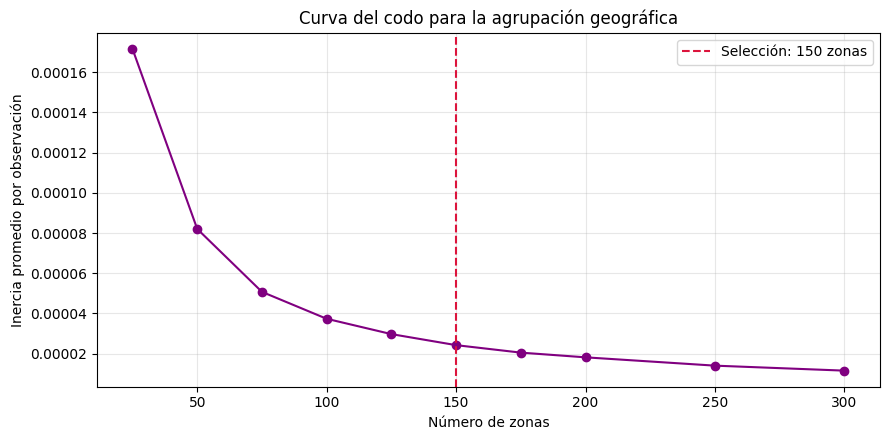

In [14]:
plt.figure(figsize=(9, 4.5))
plt.plot(
    diagnostico_k['NUMERO_ZONAS'],
    diagnostico_k['INERCIA_POR_OBSERVACION'],
    marker='o', color='purple'
)
plt.axvline(
    NUMERO_ZONAS, color='crimson', linestyle='--',
    label=f'Selección: {NUMERO_ZONAS} zonas'
)
plt.title('Curva del codo para la agrupación geográfica')
plt.xlabel('Número de zonas')
plt.ylabel('Inercia promedio por observación')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# Agrupar los casos históricos en zonas geográficas
coordenadas_train = casos_cluster_train[['LATITUD', 'LONGITUD']]
coordenadas = casos[['LATITUD', 'LONGITUD']]

kmeans = MiniBatchKMeans(
    n_clusters=NUMERO_ZONAS,
    random_state=SEMILLA,
    batch_size=10_000,
    n_init=3
)
kmeans.fit(coordenadas_train)
casos['ZONA_CIUDAD'] = kmeans.predict(coordenadas)

# Conservar los centroides para ubicar cada zona y asignar el clima
centroides_zona = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=['LATITUD_CENTROIDE', 'LONGITUD_CENTROIDE']
).rename_axis('ZONA_CIUDAD').reset_index()
centroides_zona['ZONA_CIUDAD'] = centroides_zona['ZONA_CIUDAD'].astype('int16')

print(f'Zonas construidas: {centroides_zona["ZONA_CIUDAD"].nunique():,}')
display(centroides_zona.head())

Zonas construidas: 150


,ZONA_CIUDAD,LATITUD_CENTROIDE,LONGITUD_CENTROIDE
0,0,4.616784,-74.139585
1,1,4.682372,-74.048469
2,2,4.694362,-74.110510
3,3,4.564626,-74.104038
4,4,4.622715,-74.070466


### Descriptiva de las zonas construidas

Después del ajuste se revisa la cantidad de observaciones positivas asignadas a cada zona. Estas cantidades corresponden a observaciones consolidadas de **celda-hora**, no al número bruto de accidentes. El objetivo es detectar zonas vacías o concentraciones extremas antes de construir la cuadrícula de ocurrencia.

In [16]:
resumen_zonas_cluster = (
    casos.groupby('ZONA_CIUDAD')
    .size()
    .rename('OBSERVACIONES_POSITIVAS')
    .reset_index()
    .merge(centroides_zona, on='ZONA_CIUDAD', how='left', validate='1:1')
)

assert len(resumen_zonas_cluster) == NUMERO_ZONAS
assert resumen_zonas_cluster['OBSERVACIONES_POSITIVAS'].gt(0).all()

display(resumen_zonas_cluster['OBSERVACIONES_POSITIVAS'].describe().to_frame().T)
display(resumen_zonas_cluster.nlargest(10, 'OBSERVACIONES_POSITIVAS'))

,count,mean,std,min,25%,50%,75%,max
OBSERVACIONES_POSITIVAS,150.0,3313.12,1078.853766,781.0,2562.75,3238.0,3992.75,6215.0


,ZONA_CIUDAD,OBSERVACIONES_POSITIVAS,LATITUD_CENTROIDE,LONGITUD_CENTROIDE
77,77,6215,4.631141,-74.139471
6,6,6059,4.646820,-74.127242
32,32,5922,4.628188,-74.082524
27,27,5743,4.647403,-74.062384
14,14,5583,4.601998,-74.103203
72,72,5324,4.617181,-74.088752
69,69,5222,4.635627,-74.064124
100,100,5116,4.629755,-74.151650
112,112,5065,4.625850,-74.098412
21,21,4989,4.720204,-74.053208


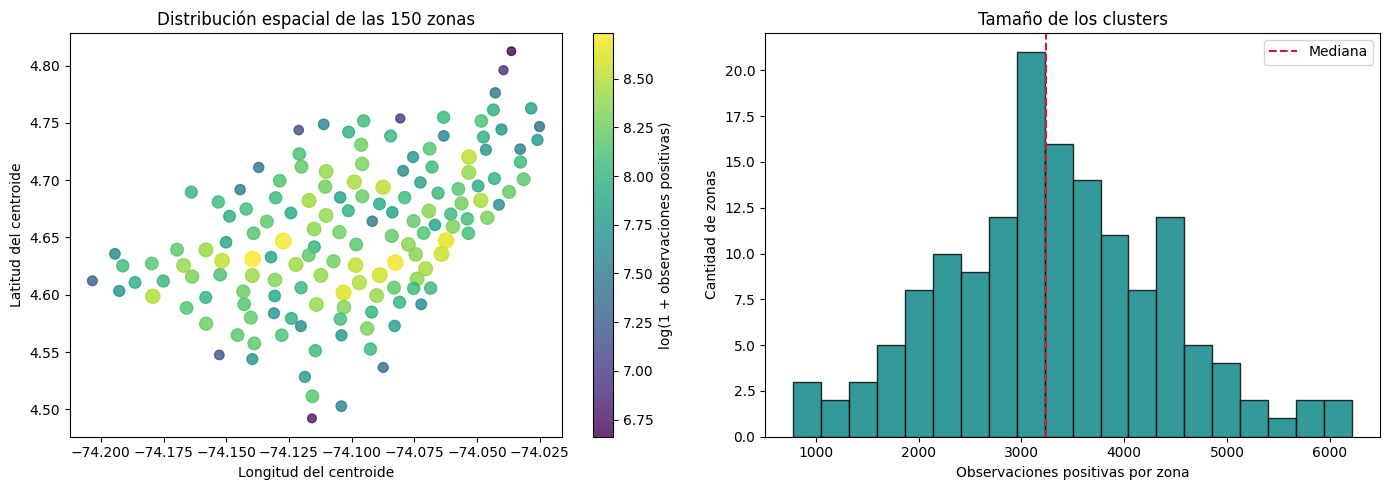

In [17]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

dispersion = ejes[0].scatter(
    resumen_zonas_cluster['LONGITUD_CENTROIDE'],
    resumen_zonas_cluster['LATITUD_CENTROIDE'],
    c=np.log1p(resumen_zonas_cluster['OBSERVACIONES_POSITIVAS']),
    s=25 + 100 * (
        resumen_zonas_cluster['OBSERVACIONES_POSITIVAS'] /
        resumen_zonas_cluster['OBSERVACIONES_POSITIVAS'].max()
    ),
    cmap='viridis', alpha=0.8
)
ejes[0].set_title('Distribución espacial de las 150 zonas')
ejes[0].set_xlabel('Longitud del centroide')
ejes[0].set_ylabel('Latitud del centroide')
fig.colorbar(
    dispersion, ax=ejes[0],
    label='log(1 + observaciones positivas)'
)

ejes[1].hist(
    resumen_zonas_cluster['OBSERVACIONES_POSITIVAS'],
    bins=20, color='teal', edgecolor='black', alpha=0.8
)
ejes[1].axvline(
    resumen_zonas_cluster['OBSERVACIONES_POSITIVAS'].median(),
    color='crimson', linestyle='--', label='Mediana'
)
ejes[1].set_title('Tamaño de los clusters')
ejes[1].set_xlabel('Observaciones positivas por zona')
ejes[1].set_ylabel('Cantidad de zonas')
ejes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
# Conservar para ocurrencia únicamente los años completos
casos_ocurrencia = casos[casos['ANIO'] <= ANIO_MAX_COMPLETO].copy()

# Consolidar la ocurrencia dentro de cada patrón anual
claves_patron = ['ANIO', 'ZONA_CIUDAD', 'MES', 'DIA_SEMANA', 'HORA']
patrones_con_accidente = (
    casos_ocurrencia.groupby(claves_patron, as_index=False)
    .agg(OCURRIO_ACCIDENTE=('OCURRIO_ACCIDENTE', 'max'))
)

anios_disponibles = sorted(casos_ocurrencia['ANIO'].unique())

# Construir todas las combinaciones posibles para cada año
cuadricula = pd.DataFrame(
    product(
        anios_disponibles,
        range(NUMERO_ZONAS),
        range(1, 13),
        range(0, 7),
        range(0, 24)
    ),
    columns=claves_patron
)

dataset_ocurrencia = cuadricula.merge(
    patrones_con_accidente,
    on=claves_patron,
    how='left',
    validate='1:1'
)
dataset_ocurrencia['OCURRIO_ACCIDENTE'] = (
    dataset_ocurrencia['OCURRIO_ACCIDENTE']
    .fillna(0)
    .astype('int8')
)
dataset_ocurrencia = dataset_ocurrencia.merge(
    centroides_zona,
    on='ZONA_CIUDAD',
    how='left',
    validate='m:1'
)

print(f'Años incluidos: {min(anios_disponibles)}–{max(anios_disponibles)}')
print(f'Combinaciones generadas: {len(dataset_ocurrencia):,}')
display(dataset_ocurrencia['OCURRIO_ACCIDENTE'].value_counts().rename('FILAS'))

Años incluidos: 2007–2025
Combinaciones generadas: 5,745,600


OCURRIO_ACCIDENTE
0    5286332
1     459268
Name: FILAS, dtype: int64

### 4.3 Clima anual de las zonas

A cada combinación anual `ANIO`–`ZONA_CIUDAD`–`MES`–`DIA_SEMANA`–`HORA` se le asigna el promedio de las observaciones meteorológicas disponibles durante ese mismo año para el nodo más cercano.

Los periodos cubiertos por `ERA5` y `ECMWF IFS` se combinan, cuando se superponen, ponderando los promedios por la cantidad de observaciones horarias. La dirección del viento se promedia de forma circular.

El clima se calcula para todas las filas, tanto para `OCURRIO_ACCIDENTE = 1` como para `OCURRIO_ACCIDENTE = 0`, evitando que la ausencia de información meteorológica revele directamente la clase objetivo.

In [19]:
# Construir el catálogo de cachés climáticos
archivos_cache = sorted(CARPETA_CACHE_CLIMA.glob('clima_*.csv'))

catalogo_nodos = []
for ruta in archivos_cache:
    muestra = pd.read_csv(ruta, nrows=1)
    catalogo_nodos.append([
        ruta.name, muestra.loc[0,'MODELO'],
        float(muestra.loc[0,'LATITUD_CELDA']),
        float(muestra.loc[0,'LONGITUD_CELDA']),
    ])
catalogo_nodos = pd.DataFrame(catalogo_nodos, columns=[
    'ARCHIVO_CACHE','MODELO_CLIMA','LATITUD_NODO','LONGITUD_NODO',
]).drop_duplicates('ARCHIVO_CACHE')

display(catalogo_nodos.groupby('MODELO_CLIMA').size().rename('NODOS').reset_index())

,MODELO_CLIMA,NODOS
0,ecmwf_ifs,15
1,era5,4


In [20]:
# Asignar a cada zona el nodo más cercano de cada modelo climático
x_zonas, y_zonas = wgs84_a_bogota.transform(
    centroides_zona['LONGITUD_CENTROIDE'].to_numpy(),
    centroides_zona['LATITUD_CENTROIDE'].to_numpy()
)
coordenadas_zonas = np.column_stack([x_zonas, y_zonas])

asignaciones_zona_clima = []
for modelo, nodos in catalogo_nodos.groupby('MODELO_CLIMA'):
    x_nodos, y_nodos = wgs84_a_bogota.transform(
        nodos['LONGITUD_NODO'].to_numpy(),
        nodos['LATITUD_NODO'].to_numpy()
    )
    arbol = cKDTree(np.column_stack([x_nodos, y_nodos]))
    _, posiciones = arbol.query(coordenadas_zonas, k=1)

    asignaciones_zona_clima.append(pd.DataFrame({
        'ZONA_CIUDAD': centroides_zona['ZONA_CIUDAD'].to_numpy(),
        'MODELO_CLIMA': modelo,
        'ARCHIVO_CACHE': nodos.iloc[posiciones]['ARCHIVO_CACHE'].to_numpy()
    }))

asignaciones_zona_clima = pd.concat(
    asignaciones_zona_clima,
    ignore_index=True
)

display(asignaciones_zona_clima.head())

,ZONA_CIUDAD,MODELO_CLIMA,ARCHIVO_CACHE
0,0,ecmwf_ifs,clima_ecmwf_ifs_4.60457_m74.12634.csv
1,1,ecmwf_ifs,clima_ecmwf_ifs_4.67487_m74.03940.csv
2,2,ecmwf_ifs,clima_ecmwf_ifs_4.67487_m74.11331.csv
3,3,ecmwf_ifs,clima_ecmwf_ifs_4.60457_m74.12634.csv
4,4,ecmwf_ifs,clima_ecmwf_ifs_4.60457_m74.05252.csv


In [21]:
# Construir promedios climáticos por nodo, año, mes, día de semana y hora
renombres_clima = {
    'temperature_2m': 'TEMPERATURA_2M',
    'relative_humidity_2m': 'HUMEDAD_RELATIVA_2M',
    'apparent_temperature': 'SENSACION_TERMICA',
    'precipitation': 'PRECIPITACION',
    'rain': 'LLUVIA',
    'cloud_cover': 'NUBOSIDAD',
    'surface_pressure': 'PRESION_SUPERFICIE',
    'wind_speed_10m': 'VELOCIDAD_VIENTO_10M'
}
variables_clima_lineales = list(renombres_clima.values())
variables_clima = variables_clima_lineales + ['DIRECCION_VIENTO_10M']
columnas_clima_origen = list(renombres_clima) + ['wind_direction_10m']
columnas_cache = ['FECHA_HORA_CLIMA', *columnas_clima_origen]

climatologias_nodo = []
for archivo in asignaciones_zona_clima['ARCHIVO_CACHE'].drop_duplicates():
    clima = pd.read_csv(
        CARPETA_CACHE_CLIMA / archivo,
        usecols=columnas_cache,
        parse_dates=['FECHA_HORA_CLIMA']
    ).dropna(subset=columnas_clima_origen)

    if clima.empty:
        warnings.warn(f'El archivo {archivo} no contiene clima completo')
        continue

    clima['ANIO'] = clima['FECHA_HORA_CLIMA'].dt.year
    clima['MES'] = clima['FECHA_HORA_CLIMA'].dt.month
    clima['DIA_SEMANA'] = clima['FECHA_HORA_CLIMA'].dt.dayofweek
    clima['HORA'] = clima['FECHA_HORA_CLIMA'].dt.hour
    direccion_radianes = np.deg2rad(clima['wind_direction_10m'])
    clima['_VIENTO_SIN'] = np.sin(direccion_radianes)
    clima['_VIENTO_COS'] = np.cos(direccion_radianes)

    agregaciones = {
        destino: (origen, 'mean')
        for origen, destino in renombres_clima.items()
    }
    agregaciones.update({
        '_VIENTO_SIN': ('_VIENTO_SIN', 'mean'),
        '_VIENTO_COS': ('_VIENTO_COS', 'mean'),
        '_OBSERVACIONES_CLIMA': ('FECHA_HORA_CLIMA', 'size')
    })

    climatologia = (
        clima.groupby(['ANIO', 'MES', 'DIA_SEMANA', 'HORA'], as_index=False)
        .agg(**agregaciones)
    )
    climatologia['ARCHIVO_CACHE'] = archivo
    climatologias_nodo.append(climatologia)

climatologias_nodo = pd.concat(climatologias_nodo, ignore_index=True)
climatologia_zonas = asignaciones_zona_clima.merge(
    climatologias_nodo,
    on='ARCHIVO_CACHE',
    how='left',
    validate='m:m'
)

# Combinar ERA5 y ECMWF IFS ponderando por sus horas disponibles
variables_ponderadas = variables_clima_lineales + ['_VIENTO_SIN', '_VIENTO_COS']
for variable in variables_ponderadas:
    climatologia_zonas[f'_SUMA_{variable}'] = (
        climatologia_zonas[variable]
        * climatologia_zonas['_OBSERVACIONES_CLIMA']
    )

columnas_suma = [f'_SUMA_{variable}' for variable in variables_ponderadas]
climatologia_zonas = (
    climatologia_zonas.groupby(claves_patron, as_index=False)[
        [*columnas_suma, '_OBSERVACIONES_CLIMA']
    ]
    .sum()
)
for variable in variables_ponderadas:
    climatologia_zonas[variable] = (
        climatologia_zonas[f'_SUMA_{variable}']
        / climatologia_zonas['_OBSERVACIONES_CLIMA']
    )

climatologia_zonas['DIRECCION_VIENTO_10M'] = (
    np.degrees(np.arctan2(
        climatologia_zonas['_VIENTO_SIN'],
        climatologia_zonas['_VIENTO_COS']
    )) % 360
)
climatologia_zonas = climatologia_zonas[claves_patron + variables_clima]

dataset_ocurrencia = dataset_ocurrencia.merge(
    climatologia_zonas,
    on=claves_patron,
    how='left',
    validate='1:1'
)

### 4.4 Variables finales del modelo de ocurrencia

Las variables espacio-temporales del dataset final son `ANIO`, `ZONA_CIUDAD`, `MES`, `DIA_SEMANA` y `HORA`. `LATITUD_CENTROIDE` y `LONGITUD_CENTROIDE` permiten representar cada zona geográficamente.

Las variables meteorológicas corresponden a promedios del mismo año y patrón temporal. `OCURRIO_ACCIDENTE` indica si la combinación se observó entre los accidentes de ese año. Antes de construir el archivo final se valida que existan exactamente 302.400 combinaciones por año y que ninguna fila quede sin clima ni coordenadas de centroide.

En el modelado, `ANIO` se utilizará únicamente para separar entrenamiento, validación y prueba; no entrará como predictor.

In [22]:
# Validar la cuadrícula anual y la integración climática
filas_por_anio = NUMERO_ZONAS * 12 * 7 * 24
filas_esperadas = len(anios_disponibles) * filas_por_anio
assert len(dataset_ocurrencia) == filas_esperadas
assert not dataset_ocurrencia.duplicated(claves_patron).any()
assert set(dataset_ocurrencia['OCURRIO_ACCIDENTE'].unique()) == {0, 1}
assert dataset_ocurrencia[variables_clima].notna().all().all()
assert dataset_ocurrencia[
    ['LATITUD_CENTROIDE', 'LONGITUD_CENTROIDE']
].notna().all().all()

print(f'Cuadrícula validada: {len(dataset_ocurrencia):,} filas')
print(f'Combinaciones por año: {filas_por_anio:,}')
display(dataset_ocurrencia.head())

Cuadrícula validada: 5,745,600 filas
Combinaciones por año: 302,400


,ANIO,ZONA_CIUDAD,MES,DIA_SEMANA,HORA,OCURRIO_ACCIDENTE,LATITUD_CENTROIDE,LONGITUD_CENTROIDE,TEMPERATURA_2M,HUMEDAD_RELATIVA_2M,SENSACION_TERMICA,PRECIPITACION,LLUVIA,NUBOSIDAD,PRESION_SUPERFICIE,VELOCIDAD_VIENTO_10M,DIRECCION_VIENTO_10M
0,2007,0,1,0,0,0,4.616784,-74.139585,13.44,85.6,13.20,0.06,0.06,77.2,754.96,4.38,99.998536
1,2007,0,1,0,1,0,4.616784,-74.139585,13.12,85.8,12.78,0.14,0.14,75.0,754.26,4.26,100.008612
2,2007,0,1,0,2,0,4.616784,-74.139585,12.38,88.0,11.96,0.00,0.00,73.8,753.40,4.36,101.412271
3,2007,0,1,0,3,0,4.616784,-74.139585,11.80,88.4,11.24,0.00,0.00,71.8,752.62,4.24,102.188664
4,2007,0,1,0,4,0,4.616784,-74.139585,11.70,87.8,11.02,0.00,0.00,71.6,752.64,4.60,100.806830


## 5. Construcción de los datasets finales para modelado

A partir de las tablas procesadas se construyen productos con distintas unidades de análisis. `DATASET_OCURRENCIA` representa combinaciones anuales de zona, mes, día y hora; `DATASET_EVENTOS` conserva una fila por accidente; y `TABLA_COMPLETA_MODELADO` integra la información necesaria para clase de accidente y estado del actor.

La lógica analítica de **PrediRuta** se estructura alrededor de tres preguntas:

1. **Ocurrencia:** ¿qué combinaciones de zona y tiempo presentan accidentes y cómo generaliza ese patrón hacia años posteriores?
2. **Tipo de evento:** dado que ocurre un siniestro, ¿qué clase de accidente es más probable?
3. **Estado del actor:** dado que una persona está involucrada, ¿qué estado podría presentar: ileso, herido o muerto?

Para ocurrencia, el clima corresponde al promedio observado en el mismo año, zona, mes, día de la semana y hora. Para los modelos condicionados a un accidente corresponde a las condiciones asociadas al evento.

> **Nota metodológica:** `ANIO` define los cortes temporales, pero no se usa como predictor. Las variables conocidas únicamente después del accidente tampoco deben utilizarse para predecir su ocurrencia.

### 5.1 Dataset de ocurrencia

### Dataset de ocurrencia

El dataset tiene como unidad de análisis una combinación **año–zona–mes–día de la semana–hora**. Para cada año se genera la cuadrícula completa de las 150 zonas y todas las combinaciones temporales.

La variable objetivo se define así:

* `1`: se registró al menos un accidente durante ese año para la combinación.
* `0`: no se registraron accidentes durante ese año para la combinación.

Cada fila incluye el centroide de la zona y el clima promedio observado para el mismo año y patrón temporal. Se comparan escenarios con y sin clima sobre exactamente las mismas observaciones y cortes temporales.

La inclusión del año permite evaluar el modelo sobre periodos posteriores. Sin embargo, la salida sigue representando la clasificación de una combinación anual y no una probabilidad individual calibrada por viaje, ya que no se dispone de exposición vehicular para cada celda-hora.

In [23]:
# Definir grupos de predictores para el modelo de ocurrencia
PREDICTORES_ESPACIOTEMPORALES = [
    'MES',
    'DIA_SEMANA',
    'HORA',
    'ZONA_CIUDAD'
]

PREDICTORES_CLIMA = variables_clima.copy()

# ANIO se conserva para los cortes, pero no forma parte de los predictores
columnas_ocurrencia = [
    'ANIO',
    *PREDICTORES_ESPACIOTEMPORALES,
    'LATITUD_CENTROIDE',
    'LONGITUD_CENTROIDE',
    *PREDICTORES_CLIMA,
    'OCURRIO_ACCIDENTE'
]

DATASET_OCURRENCIA = (
    dataset_ocurrencia[columnas_ocurrencia]
    .sort_values(['ANIO', 'ZONA_CIUDAD', 'MES', 'DIA_SEMANA', 'HORA'])
    .reset_index(drop=True)
)

display(DATASET_OCURRENCIA)

print(f'Casos con accidente: '
      f'{DATASET_OCURRENCIA["OCURRIO_ACCIDENTE"].eq(1).sum():,}')
print(f'Combinaciones sin accidente: '
      f'{DATASET_OCURRENCIA["OCURRIO_ACCIDENTE"].eq(0).sum():,}')

,ANIO,MES,DIA_SEMANA,HORA,ZONA_CIUDAD,LATITUD_CENTROIDE,LONGITUD_CENTROIDE,TEMPERATURA_2M,HUMEDAD_RELATIVA_2M,SENSACION_TERMICA,PRECIPITACION,LLUVIA,NUBOSIDAD,PRESION_SUPERFICIE,VELOCIDAD_VIENTO_10M,DIRECCION_VIENTO_10M,OCURRIO_ACCIDENTE
0,2007,1,0,0,0,4.616784,-74.139585,13.440,85.60,13.200,0.06,0.06,77.20,754.960,4.380,99.998536,0
1,2007,1,0,1,0,4.616784,-74.139585,13.120,85.80,12.780,0.14,0.14,75.00,754.260,4.260,100.008612,0
2,2007,1,0,2,0,4.616784,-74.139585,12.380,88.00,11.960,0.00,0.00,73.80,753.400,4.360,101.412271,0
3,2007,1,0,3,0,4.616784,-74.139585,11.800,88.40,11.240,0.00,0.00,71.80,752.620,4.240,102.188664,0
4,2007,1,0,4,0,4.616784,-74.139585,11.700,87.80,11.020,0.00,0.00,71.60,752.640,4.600,100.806830,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5745595,2025,12,6,19,149,4.671981,-74.083758,14.400,75.00,14.125,0.00,0.00,95.75,756.500,2.200,211.417639,0
5745596,2025,12,6,20,149,4.671981,-74.083758,13.675,78.50,13.225,0.00,0.00,83.00,756.675,3.275,157.449117,0
5745597,2025,12,6,21,149,4.671981,-74.083758,12.900,82.00,12.375,0.00,0.00,59.25,756.725,3.500,143.968091,0
5745598,2025,12,6,22,149,4.671981,-74.083758,12.300,85.75,11.825,0.00,0.00,49.00,756.500,3.000,125.772654,0


Casos con accidente: 459,268
Combinaciones sin accidente: 5,286,332


### 5.2 Dataset de eventos ocurridos

El segundo dataset contiene únicamente accidentes que efectivamente ocurrieron y se utilizará para desarrollar modelos complementarios condicionados a la existencia de un evento.

A partir de este conjunto se podrán analizar dos variables objetivo:

* `CLASE_ACCIDENTE`: permite estimar qué tipo de accidente podría presentarse una vez ocurre un evento.
* `OBJETIVO_GRAVE`: permite estimar la probabilidad de que el accidente corresponda a un evento grave.

In [24]:
# Construir dataset de accidentes ocurridos directamente desde ACCIDENTE + CLIMA
eventos = (
    TABLAS_CODIFICADAS['ACCIDENTE']
    .merge(
        TABLAS_CODIFICADAS['CLIMA'],
        on='CLIMA_ID',
        how='left',
        validate='m:1'
    )
    .copy()
)

# Asignar cada accidente a una celda de 500 m para los modelos de evento
x_evento, y_evento = wgs84_a_bogota.transform(
    eventos['LONGITUD'].to_numpy(),
    eventos['LATITUD'].to_numpy()
)

eventos['CELDA_X'] = (
    np.floor(np.asarray(x_evento) / TAMANO_CELDA_METROS)
    .astype('int32')
)

eventos['CELDA_Y'] = (
    np.floor(np.asarray(y_evento) / TAMANO_CELDA_METROS)
    .astype('int32')
)

eventos['CELDA_ID'] = (
    eventos['CELDA_X'].astype(str)
    + '_'
    + eventos['CELDA_Y'].astype(str)
)

# Derivar variables temporales
eventos['ANIO'] = eventos['FECHA_HORA'].dt.year
eventos['MES'] = eventos['FECHA_HORA'].dt.month
eventos['DIA_SEMANA'] = eventos['FECHA_HORA'].dt.dayofweek
eventos['HORA'] = eventos['FECHA_HORA'].dt.hour
eventos['FIN_SEMANA'] = (
    eventos['DIA_SEMANA'].isin([5, 6]).astype(int)
)

# Predictores disponibles antes o durante una consulta futura
PREDICTORES_EVENTO = [
    'CELDA_X',
    'CELDA_Y',
    'ANIO',
    'MES',
    'DIA_SEMANA',
    'HORA',
    'FIN_SEMANA'
]

columnas_eventos = [
    'ACCIDENTE_ID',
    'CELDA_ID',
    'FECHA_HORA',
    'LATITUD',
    'LONGITUD',
    *PREDICTORES_EVENTO,
    *PREDICTORES_CLIMA,
    'CLASE_ACCIDENTE',
    'OBJETIVO_GRAVE'
]

DATASET_EVENTOS = (
    eventos[columnas_eventos]
    .sort_values('FECHA_HORA')
    .reset_index(drop=True)
)

display(DATASET_EVENTOS)

,ACCIDENTE_ID,CELDA_ID,FECHA_HORA,LATITUD,LONGITUD,CELDA_X,CELDA_Y,ANIO,MES,DIA_SEMANA,...,HUMEDAD_RELATIVA_2M,SENSACION_TERMICA,PRECIPITACION,LLUVIA,NUBOSIDAD,PRESION_SUPERFICIE,VELOCIDAD_VIENTO_10M,DIRECCION_VIENTO_10M,CLASE_ACCIDENTE,OBJETIVO_GRAVE
0,12798,1999_2007,2007-01-01 00:00:00,4.629939,-74.080151,1999,2007,2007,1,0,...,88,10.7,0.0,0.0,97,739.5,5.7,108,7,1
1,10819805,1999_2007,2007-01-01 00:00:00,4.629939,-74.080151,1999,2007,2007,1,0,...,88,10.7,0.0,0.0,97,739.5,5.7,108,7,1
2,13707,1994_2032,2007-01-01 00:45:00,4.742590,-74.100732,1994,2032,2007,1,0,...,89,9.2,0.0,0.0,95,738.2,6.0,107,4,0
3,10819463,1994_2032,2007-01-01 00:45:00,4.742590,-74.100732,1994,2032,2007,1,0,...,89,9.2,0.0,0.0,95,738.2,6.0,107,4,0
4,10861126,1976_2007,2007-01-01 00:50:00,4.628402,-74.184284,1976,2007,2007,1,0,...,88,11.3,0.0,0.0,89,755.4,5.4,94,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895341,11345986,1979_1995,2026-08-09 20:00:00,4.577361,-74.170757,1979,1995,2026,8,6,...,49,13.4,0.0,0.0,27,760.5,10.4,116,4,1
895342,11345978,2010_2021,2026-08-10 08:26:00,4.692480,-74.029778,2010,2021,2026,8,0,...,73,11.4,0.0,0.0,27,754.3,8.2,157,1,1
895343,11345977,1986_1991,2026-08-10 14:50:00,4.557907,-74.138602,1986,1991,2026,8,0,...,54,14.3,0.0,0.0,9,753.5,20.8,128,1,1
895344,11346001,1991_2009,2026-08-12 13:20:00,4.639754,-74.116059,1991,2009,2026,8,2,...,40,19.2,0.0,0.0,100,761.3,14.1,153,4,1


### 5.3 Tabla completa de modelado para clase y estado

`TABLA_COMPLETA_MODELADO` centraliza la información que comparten los modelos condicionados a la ocurrencia de un accidente. La tabla conserva una fila por actor cuando el evento tiene actores registrados. Para los accidentes sin actores se mantiene una fila con las variables del evento y los campos del actor vacíos; esto evita perder accidentes al construir el modelo de clase.

La asignación de `ZONA_CIUDAD` reutiliza directamente el `MiniBatchKMeans` ajustado para el modelo de ocurrencia: se calcula el centro de cada celda de 500 m y se aplica `predict`, sin volver a entrenar la clusterización. Por tanto, los tres modelos utilizan exactamente las mismas 150 zonas.

Uso previsto de la tabla:

* **Clase de accidente:** seleccionar una sola fila por `ACCIDENTE_ID` y utilizar únicamente variables espaciales, temporales, meteorológicas y de la vía. Las variables del actor y del vehículo no se emplean como predictores de la clase.
* **Estado del actor:** conservar únicamente las filas con `ACTOR_ID` y utilizar `ESTADO` como objetivo. En este caso sí pueden evaluarse las características del actor y del vehículo según el escenario planteado.

Los identificadores `ACTOR_ID` y `VEHICULO_ID` se conservan exclusivamente para mantener la trazabilidad y efectuar uniones o validaciones; no se utilizan como predictores.

In [25]:
# Asignar a cada celda de evento una de las mismas 150 zonas de ocurrencia
celdas_evento = DATASET_EVENTOS[
    ['CELDA_ID', 'CELDA_X', 'CELDA_Y']
].drop_duplicates().copy()

x_centro_evento = (
    celdas_evento['CELDA_X'].to_numpy() + 0.5
) * TAMANO_CELDA_METROS
y_centro_evento = (
    celdas_evento['CELDA_Y'].to_numpy() + 0.5
) * TAMANO_CELDA_METROS

lon_centro_evento, lat_centro_evento = bogota_a_wgs84.transform(
    x_centro_evento,
    y_centro_evento
)
celdas_evento['LATITUD_CELDA'] = lat_centro_evento
celdas_evento['LONGITUD_CELDA'] = lon_centro_evento
coordenadas_centro_evento = celdas_evento[
    ['LATITUD_CELDA', 'LONGITUD_CELDA']
].rename(columns={
    'LATITUD_CELDA': 'LATITUD',
    'LONGITUD_CELDA': 'LONGITUD'
})
celdas_evento['ZONA_CIUDAD'] = kmeans.predict(
    coordenadas_centro_evento
).astype('int16')

eventos_modelado = (
    DATASET_EVENTOS
    .merge(
        celdas_evento[['CELDA_ID', 'ZONA_CIUDAD']],
        on='CELDA_ID',
        how='left',
        validate='m:1'
    )
    .merge(
        centroides_zona,
        on='ZONA_CIUDAD',
        how='left',
        validate='m:1'
    )
)

# Incorporar variables de vía sin agregar resultados posteriores al accidente
COLUMNAS_VIA_CATEGORICAS = [
    'GEOMETRIA_PLANTA', 'GEOMETRIA_TERRENO', 'GEOMETRIA_SECCION',
    'SENTIDO_VIA', 'SUPERFICIE_RODADURA', 'ESTADO_VIA',
    'CONDICION_VIA', 'ILUMINACION_ARTIFICIAL', 'SEMAFORO'
]
COLUMNAS_VIA_NUMERICAS = ['N_CALZADAS', 'N_CARRILES']
COLUMNAS_VIA = [*COLUMNAS_VIA_CATEGORICAS, *COLUMNAS_VIA_NUMERICAS]

vias_modelado = TABLAS_CODIFICADAS['VIA'][
    ['ACCIDENTE_ID', *COLUMNAS_VIA]
].copy()
eventos_modelado = eventos_modelado.merge(
    vias_modelado,
    on='ACCIDENTE_ID',
    how='left',
    validate='1:1'
)
eventos_modelado[COLUMNAS_VIA_CATEGORICAS] = (
    eventos_modelado[COLUMNAS_VIA_CATEGORICAS]
    .fillna(0)
    .astype(int)
)

# Conservar todos los accidentes: una fila por actor o una fila vacía si no hay actor
actores_modelado = TABLAS_CODIFICADAS['ACTOR_VIAL'][
    ['ACCIDENTE_ID', 'ACTOR_ID', 'VEHICULO_ID', 'CONDICION', 'ESTADO', 'GENERO', 'EDAD']
].copy()
vehiculos_modelado = TABLAS_CODIFICADAS['VEHICULO'][
    ['ACCIDENTE_ID', 'VEHICULO_ID', 'CLASE', 'SERVICIO']
].rename(columns={
    'CLASE': 'CLASE_VEHICULO',
    'SERVICIO': 'SERVICIO_VEHICULO'
})

TABLA_COMPLETA_MODELADO = (
    eventos_modelado
    .merge(actores_modelado, on='ACCIDENTE_ID', how='left', validate='1:m')
    .merge(
        vehiculos_modelado,
        on=['ACCIDENTE_ID', 'VEHICULO_ID'],
        how='left',
        validate='m:1'
    )
)

# Añadir etiquetas legibles para que los modelos no dependan de otro archivo
catalogo_clase = (
    DICCIONARIO_CATEGORIAS.query(
        "TABLA == 'ACCIDENTE' and COLUMNA == 'CLASE_ACCIDENTE'"
    )
    .set_index('CODIGO')['DESCRIPCION']
    .to_dict()
)
catalogo_estado = (
    DICCIONARIO_CATEGORIAS.query(
        "TABLA == 'ACTOR_VIAL' and COLUMNA == 'ESTADO'"
    )
    .set_index('CODIGO')['DESCRIPCION']
    .to_dict()
)
TABLA_COMPLETA_MODELADO['CLASE_ACCIDENTE_DESC'] = (
    TABLA_COMPLETA_MODELADO['CLASE_ACCIDENTE'].map(catalogo_clase)
)
TABLA_COMPLETA_MODELADO['ESTADO_DESC'] = (
    TABLA_COMPLETA_MODELADO['ESTADO'].map(catalogo_estado)
)

columnas_modelado = [
    'ACCIDENTE_ID', 'ACTOR_ID', 'VEHICULO_ID',
    'FECHA_HORA', 'LATITUD', 'LONGITUD',
    'CELDA_ID', 'CELDA_X', 'CELDA_Y',
    'ZONA_CIUDAD', 'LATITUD_CENTROIDE', 'LONGITUD_CENTROIDE',
    'ANIO', 'MES', 'DIA_SEMANA', 'HORA', 'FIN_SEMANA',
    *PREDICTORES_CLIMA,
    *COLUMNAS_VIA,
    'CLASE_ACCIDENTE', 'CLASE_ACCIDENTE_DESC', 'OBJETIVO_GRAVE',
    'CONDICION', 'ESTADO', 'ESTADO_DESC', 'GENERO', 'EDAD',
    'CLASE_VEHICULO', 'SERVICIO_VEHICULO'
]
TABLA_COMPLETA_MODELADO = (
    TABLA_COMPLETA_MODELADO[columnas_modelado]
    .sort_values(['FECHA_HORA', 'ACCIDENTE_ID', 'ACTOR_ID'], na_position='last')
    .reset_index(drop=True)
)

# Validar granularidad y cobertura para ambos modelos
accidentes_sin_actor = ~DATASET_EVENTOS['ACCIDENTE_ID'].isin(
    actores_modelado['ACCIDENTE_ID']
)
filas_esperadas = len(actores_modelado) + accidentes_sin_actor.sum()

assert len(TABLA_COMPLETA_MODELADO) == filas_esperadas
assert TABLA_COMPLETA_MODELADO['ACCIDENTE_ID'].nunique() == len(DATASET_EVENTOS)
assert TABLA_COMPLETA_MODELADO.loc[
    TABLA_COMPLETA_MODELADO['ACTOR_ID'].notna(), 'ACTOR_ID'
].is_unique
assert TABLA_COMPLETA_MODELADO['ZONA_CIUDAD'].notna().all()
assert TABLA_COMPLETA_MODELADO['ZONA_CIUDAD'].nunique() == NUMERO_ZONAS

print(f'Filas totales: {len(TABLA_COMPLETA_MODELADO):,}')
print(f'Accidentes: {TABLA_COMPLETA_MODELADO["ACCIDENTE_ID"].nunique():,}')
print(f'Actores: {TABLA_COMPLETA_MODELADO["ACTOR_ID"].notna().sum():,}')
print(f'Accidentes sin actor: {accidentes_sin_actor.sum():,}')
display(TABLA_COMPLETA_MODELADO.head())

Filas totales: 1,928,614
Accidentes: 895,346
Actores: 1,927,486
Accidentes sin actor: 1,128


,ACCIDENTE_ID,ACTOR_ID,VEHICULO_ID,FECHA_HORA,LATITUD,LONGITUD,CELDA_ID,CELDA_X,CELDA_Y,ZONA_CIUDAD,...,CLASE_ACCIDENTE,CLASE_ACCIDENTE_DESC,OBJETIVO_GRAVE,CONDICION,ESTADO,ESTADO_DESC,GENERO,EDAD,CLASE_VEHICULO,SERVICIO_VEHICULO
0,12798,97170.0,1.279802e+06,2007-01-01 00:00:00,4.629939,-74.080151,1999_2007,1999,2007,32,...,7,VOLCAMIENTO,1,4.0,1.0,HERIDO,2.0,12.0,13.0,3.0
1,10819805,13443090.0,1.081981e+09,2007-01-01 00:00:00,4.629939,-74.080151,1999_2007,1999,2007,32,...,7,VOLCAMIENTO,1,3.0,1.0,HERIDO,2.0,12.0,13.0,3.0
2,13707,98533.0,1.370702e+06,2007-01-01 00:45:00,4.742590,-74.100732,1994_2032,1994,2032,12,...,4,CHOQUE,0,3.0,2.0,ILESO,2.0,41.0,1.0,4.0
3,13707,98534.0,1.370703e+06,2007-01-01 00:45:00,4.742590,-74.100732,1994_2032,1994,2032,12,...,4,CHOQUE,0,3.0,2.0,ILESO,2.0,60.0,1.0,4.0
4,10819463,13385884.0,1.081946e+09,2007-01-01 00:45:00,4.742590,-74.100732,1994_2032,1994,2032,12,...,4,CHOQUE,0,3.0,2.0,ILESO,2.0,41.0,1.0,4.0


### 5.4 Estructura de experimentación

Los productos construidos permiten plantear los tres objetivos predictivos con una fuente explícita para cada unidad de análisis.

| Componente | Dataset | Selección de filas | Variable objetivo |
| --- | --- | --- | --- |
| Ocurrencia | `DATASET_OCURRENCIA` | Una fila por año–zona–mes–día–hora | `OCURRIO_ACCIDENTE` |
| Clase de accidente | `TABLA_COMPLETA_MODELADO` | Una fila por `ACCIDENTE_ID` | `CLASE_ACCIDENTE` |
| Estado del actor | `TABLA_COMPLETA_MODELADO` | Filas con `ACTOR_ID` | `ESTADO` |

Para clase y estado, la tabla compartida garantiza que zona, tiempo, vía y clima provengan de la misma preparación. Cada notebook selecciona su granularidad y predictores antes de dividir los datos.

In [26]:
# Resumen de los datasets disponibles para la etapa de modelado
resumen_modelado = pd.DataFrame([
    {
        'DATASET': 'DATASET_OCURRENCIA',
        'UNIDAD_ANALISIS': 'Año-zona-mes-día-hora',
        'FILAS': len(DATASET_OCURRENCIA),
        'COLUMNAS': len(DATASET_OCURRENCIA.columns),
        'OBJETIVO': 'OCURRIO_ACCIDENTE'
    },
    {
        'DATASET': 'DATASET_EVENTOS',
        'UNIDAD_ANALISIS': 'Accidente',
        'FILAS': len(DATASET_EVENTOS),
        'COLUMNAS': len(DATASET_EVENTOS.columns),
        'OBJETIVO': 'Fuente intermedia por accidente'
    },
    {
        'DATASET': 'TABLA_COMPLETA_MODELADO',
        'UNIDAD_ANALISIS': 'Actor; accidente si no tiene actor',
        'FILAS': len(TABLA_COMPLETA_MODELADO),
        'COLUMNAS': len(TABLA_COMPLETA_MODELADO.columns),
        'OBJETIVO': 'CLASE_ACCIDENTE / ESTADO'
    }
])

display(resumen_modelado)

,DATASET,UNIDAD_ANALISIS,FILAS,COLUMNAS,OBJETIVO
0,DATASET_OCURRENCIA,Año-zona-mes-día-hora,5745600,17,OCURRIO_ACCIDENTE
1,DATASET_EVENTOS,Accidente,895346,23,Fuente intermedia por accidente
2,TABLA_COMPLETA_MODELADO,Actor; accidente si no tiene actor,1928614,47,CLASE_ACCIDENTE / ESTADO


## 6. Exportación

Como resultado del procesamiento se exportan cuatro productos finales:

1. `DICCIONARIO_CATEGORIAS.csv`: documenta la codificación de las variables categóricas.
2. `DATASET_OCURRENCIA.csv`: contiene la cuadrícula anual de zona–mes–día–hora, la etiqueta de ocurrencia y el clima del mismo año.
3. `DATASET_EVENTOS.csv`: conserva una fila por accidente y funciona como producto intermedio.
4. `TABLA_COMPLETA_MODELADO.csv`: es la única tabla completa y la fuente compartida por los modelos de clase y estado.

Los notebooks de modelado seleccionan las filas y los predictores apropiados para cada objetivo. No se genera una segunda tabla completa para análisis.

In [27]:
# Exportar productos finales
DICCIONARIO_CATEGORIAS.to_csv(
    RUTA_DICCIONARIO,
    index=False,
    encoding='utf-8-sig'
)

DATASET_OCURRENCIA.to_csv(
    RUTA_OCURRENCIA,
    index=False,
    encoding='utf-8-sig'
)

DATASET_EVENTOS.to_csv(
    RUTA_EVENTOS,
    index=False,
    encoding='utf-8-sig'
)

TABLA_COMPLETA_MODELADO.to_csv(
    RUTA_MODELADO,
    index=False,
    encoding='utf-8-sig'
)

print('Archivos generados:')
print(f'- Diccionario:       {DICCIONARIO_CATEGORIAS.shape}')
print(f'- Ocurrencia:        {DATASET_OCURRENCIA.shape}')
print(f'- Eventos:           {DATASET_EVENTOS.shape}')
print(f'- Tabla de modelado: {TABLA_COMPLETA_MODELADO.shape}')

Archivos generados:
- Diccionario:       (237, 4)
- Ocurrencia:        (5745600, 17)
- Eventos:           (895346, 23)
- Tabla de modelado: (1928614, 47)
